In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import pipeline as pipeline
import copy
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [12]:
import os

def list_all_csv_files(dir_path):
    """
    주어진 dir_path 아래의 모든 하위 디렉토리를 포함하여
    .csv 확장자를 가진 파일의 전체 경로를 리스트로 반환합니다.
    """
    csv_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

dir_path = './data_ready/input_data'
csv_files = list_all_csv_files(dir_path)
csv_files


['./data_ready/input_data/0/joined_input_data_European_ancestry_Late-dry.csv',
 './data_ready/input_data/0/joined_input_data_European_ancestry_Early.csv',
 './data_ready/input_data/0/joined_input_data_European_ancestry_Intermediate.csv',
 './data_ready/input_data/0/joined_input_data_European_ancestry_Late-wet.csv',
 './data_ready/input_data/1/joined_input_data_Asian_ancestry_Early.csv',
 './data_ready/input_data/1/joined_input_data_Asian_ancestry_Late-wet.csv',
 './data_ready/input_data/1/joined_input_data_Asian_ancestry_Late-dry.csv',
 './data_ready/input_data/1/joined_input_data_Asian_ancestry_Intermediate.csv',
 './data_ready/input_data/4/joined_input_data_NR_Early.csv',
 './data_ready/input_data/4/joined_input_data_NR_Late-dry.csv',
 './data_ready/input_data/4/joined_input_data_NR_Intermediate.csv',
 './data_ready/input_data/4/joined_input_data_NR_Late-wet.csv',
 './data_ready/input_data/3/joined_input_data_African_ancestry_Late-dry.csv',
 './data_ready/input_data/3/joined_input_da

In [ ]:
basedir = '/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/data_ready/params'

input_data_path = csv_files[0]
output_template_path = f'{basedir}/output_template.csv'
parameters_path = f'{basedir}/parameters.jsonc'
hierarchy_path = f'{basedir}/hierarchy.json' 


In [16]:
pm_model = pipeline.initiliaze_pipeline(
    input_data_path=input_data_path,
    output_template_path=output_template_path,
    parameters_path=parameters_path,
    hierarchy_path=hierarchy_path,
    verbose=True
)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
number of rows: 114
number of unique location_id: 12
number of nodes: 233
number of edges: 232


In [17]:
rate_types = ['beta_binom', 'binom', 'neg_binom', 'poisson', 'log_normal', 'normal', 'offset_log_normal']
rate_type = rate_types[2]
# 모델 객체 복제
pm_model_copy = copy.deepcopy(pm_model)

# 필요하다면 shared_data 같은 dict도 별도로 복사
pm_model_copy.shared_data = copy.deepcopy(pm_model.shared_data)

pipeline.generate_pymc_objects(pm_model_copy, rate_type=rate_type, include_covariates=True)

Standard errors replaced: 0
Effective sample sizes filled: 0


In [19]:
map_estimate = pipeline.return_map_estimate(pm_model=pm_model_copy, verbose=True)

INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


In [20]:
idata = pipeline.return_idata(pm_model     = pm_model_copy, 
                            map_estimate   = map_estimate, 
                            draws          = 4000,
                            tune           = 1000,
                            chains         = 8,
                            cores          = 4,
                            target_accept  = 0.9,
                            max_treedepth  = 10,
                            use_advi       = False,
                            use_metropolis = True,
                            verbose=True
                            ) 
# 198.3초 소요

INFO:pipeline:  ▶ Metropolis 샘플링 수행 중...
Multiprocess sampling (8 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (8 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha_p_100]
INFO:pymc:>Metropolis: [alpha_p_100]
>Metropolis: [alpha_p_102]
INFO

Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 70 seconds.
INFO:pymc:Sampling 8 chains for 1_000 tune and 4_000 draw iterations (8_000 + 32_000 draws total) took 70 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
INFO:pipeline:[asr] 전체 소요 시간: 121.0초


In [21]:
import numpy as np
import arviz as az

# 1) posterior 변수 이름 중에 'beta' 포함된 것만 추출
beta_vars = [var for var in idata.posterior.data_vars if 'beta' in var]
print("Found beta variables:", beta_vars)

# 2) NumPy로 직접 mean 계산 (chain, draw 차원 평균)
mean_beta = {
    var: idata.posterior[var].values.mean(axis=(0, 1))
    for var in beta_vars
}

# 결과 출력
for var, m in mean_beta.items():
    print(f"{var} mean:\n{m}\n")


# —— 또는 —— #

# 3) ArviZ의 summary로 한 번에 보기
summary_beta = az.summary(idata, var_names=beta_vars)
print(summary_beta[['mean']])

# 2) 90% HDI로 변경하고 싶을 때
summary_beta_90 = az.summary(
    idata,
    var_names=beta_vars,
    stat_focus="mean",
    hdi_prob=0.90,          # 90% HDI
    round_to=4
)
print(summary_beta_90[['mean', 'hdi_5%', 'hdi_95%']])



Found beta variables: ['beta_p_x_lpa', 'beta_p_x_sdi', 'beta_p_x_sev', 'beta_p_x_sex']
beta_p_x_lpa mean:
0.06284364677850351

beta_p_x_sdi mean:
0.1406493105615733

beta_p_x_sev mean:
0.038574937259363604

beta_p_x_sex mean:
0.06492205774040216

               mean
beta_p_x_lpa  0.063
beta_p_x_sdi  0.141
beta_p_x_sev  0.039
beta_p_x_sex  0.065
                mean  hdi_5%  hdi_95%
beta_p_x_lpa  0.0628 -0.1672   0.2994
beta_p_x_sdi  0.1406 -0.0459   0.3217
beta_p_x_sev  0.0386 -0.1056   0.1990
beta_p_x_sex  0.0649 -0.0551   0.1958


In [23]:
summary_df = pipeline.return_rhat(idata)

Total vars:    802
R-hat > 1.01:  294
R-hat <= 1.01:  448
R-hat missing: 60
<xarray.Dataset> Size: 12kB
Dimensions:               (knot: 9, age: 101, cum_sum_mu_p_dim_0: 101,
                           mu_interval_p_dim_0: 114, pi_p_dim_0: 114,
                           obs_dim: 114, p_pred_p_dim_0: 114)
Coordinates:
  * knot                  (knot) float64 72B 0.0 30.0 40.0 ... 80.0 90.0 100.0
  * age                   (age) float64 808B 0.0 1.0 2.0 3.0 ... 98.0 99.0 100.0
  * cum_sum_mu_p_dim_0    (cum_sum_mu_p_dim_0) int64 808B 0 1 2 3 ... 98 99 100
  * mu_interval_p_dim_0   (mu_interval_p_dim_0) int64 912B 0 1 2 ... 111 112 113
  * pi_p_dim_0            (pi_p_dim_0) int64 912B 0 1 2 3 4 ... 110 111 112 113
  * obs_dim               (obs_dim) int64 912B 0 1 2 3 4 ... 109 110 111 112 113
  * p_pred_p_dim_0        (p_pred_p_dim_0) int64 912B 0 1 2 3 ... 111 112 113
Data variables: (12/42)
    gamma_p               (knot) float64 72B 1.006 1.008 1.01 ... 1.049 1.047
    sigma_alpha_p_

In [56]:
pred = pipeline.predict_for(pm_model            = pm_model_copy,
                            idata               = idata, 
                            root_area           = 'Global',
                            root_sex            = 'Both',
                            root_year           = 'all',
                            location_id                = 1,
                            sex_name                 = 'Both',
                            year_id                = 2021,
                            population_weighted = True,
                            lower               = 0.0,
                            upper               = 1.0,
                            )

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/spline.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/priors.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/age_groups.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/covariates.py
/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/model/likelihood.py
33 Both 2021
MultiIndex([(  6, 'Both', 1990),
            (  6, 'Both', 1991),
            (  6, 'Both', 1992),
            (  6, 'Both', 1993),
            (  6, 'Both', 1994),
            (  6, 'Both', 1995),
            (  6, 'Both', 1996),
            (  6, 'Both', 1997),
            (  6, 'Both', 1998),
            (  6, 'Both', 1999),
            ...
            (522, 'Male', 2012),
            (522, 'Male', 2013),
            (522, 'Male', 2014),
            (522, 'Male', 2015),
            (522, 'Male', 2016),
            (522, 'Male', 2017),
            (522, 'Male', 2018),
            (522, 'Male', 2019),
            (522, 'Male', 2020

In [57]:
import pandas as pd
import numpy as np

# === 1) pred 불러오기 ===
# 예: pred = pipeline.predict_for(...)
# pred.shape == (n_samples, n_ages)  # 여기서는 (32000, 101)

# === 2) 통계량 계산 ===
mean_vals    = pred.mean(axis=0)
lower_vals   = np.percentile(pred,  2.5, axis=0)
upper_vals   = np.percentile(pred, 97.5, axis=0)

# === 3) DataFrame 생성 ===
ages = np.arange(pred.shape[1])  # 0,1,2,...,100

df = pd.DataFrame({
    'mean'     : mean_vals,
    'lower_ci' : lower_vals,
    'upper_ci' : upper_vals
}, index=ages)

df.index.name = 'age'

# === 4) CSV로 저장 ===
out_path = f'prevalence_2021.csv'
df.to_csv(out_path)
print(f"Saved summary to {out_path}")


Saved summary to prevalence_2021.csv


In [10]:
results = pipeline.world_map(
    pm_model,
    idata,
    detailed_pop_path='pop2019_by_ages.csv',
    year=2019,
    ages_of_interest=list(range(30,101)),
    output_csv_path=f'regional_prev_{label}_2019.csv'
)


Saved regional prevalence to 'regional_prev_early_nr_2019.csv'


/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:845: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  df=data,


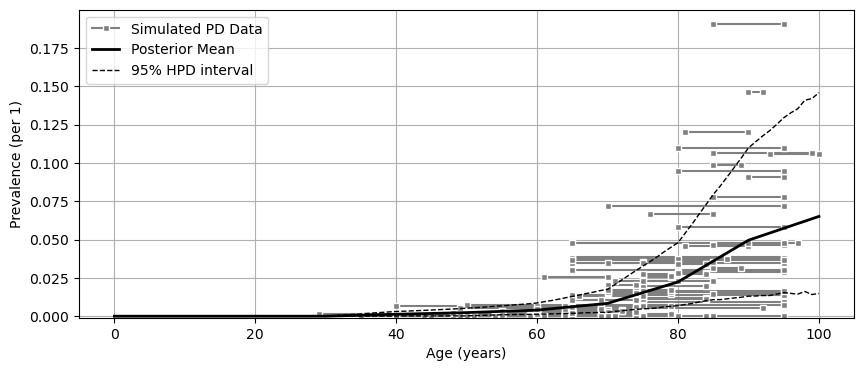

In [59]:
pipeline.visualize_pred(pred, pm_model_copy.shared_data["data"])

In [12]:
# 3) (간단) pickle로 저장
import pickle
pkl_path = f"./idata_{label}_2019.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(idata, f)
print(f"Pickled InferenceData to {pkl_path}")

Pickled InferenceData to ./idata_early_nr_2019.pkl
